# Harmonic Oscillator Phase Space Trajectory

Number of steps: 56198


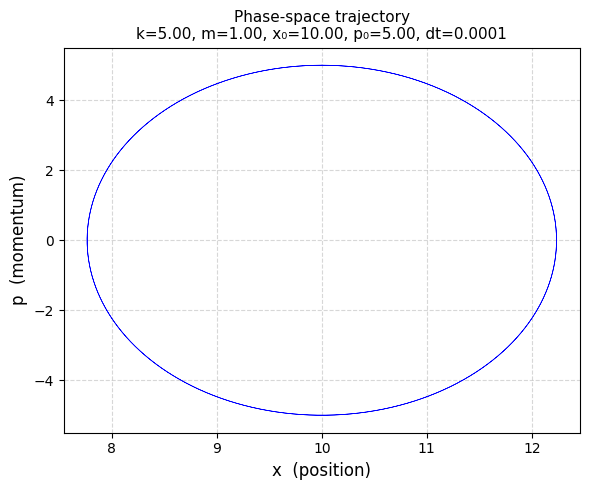

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

x0 = 10       # equilibrium position
p0 = 5      # initial momentum
k  = 5    # spring constant
m  = 1    # mass
dt = 0.0001 # time step
E = (p0**2) / (2 * m) + 0.5 * k * (x0 - x0)**2 # total energy (constant)
T = 4 * np.pi * np.sqrt(m / k) # period of oscillation
steps = int(T//dt)
print(f"Number of steps: {steps}")

def simul(steps, x0, p0, k, m, dt):
    plot_x=[]
    plot_p=[]
    plot_E=[]
    x = np.zeros(steps)
    p = np.zeros(steps)
    x[0], p[0] = x0, p0
    for i in range(1, steps):
        x[i] = x[i-1] + (p[i-1] / m) * dt + 0.5 * (-k * (x[i-1] - x0) / m) * dt**2
        p[i] = p[i-1] + 0.5 * ((-k * (x[i-1] - x0)) + (-k * (x[i] - x0)))/m * dt
        plot_x.append(x[i])
        plot_p.append(p[i])
        plot_E.append((p[i]**2) / (2 * m) + 0.5 * k * (x[i] - x0)**2)
    return x, p, plot_x, plot_p, plot_E

x, p, plot_x, plot_p, plot_E = simul(steps, x0, p0, k, m, dt)

# --- Phase-space plot (x vs p) ---
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.plot(x, p, color="blue", linewidth=0.5)
ax.set_xlabel("x  (position)", fontsize=12)
ax.set_ylabel("p  (momentum)", fontsize=12)
ax.set_title(f"Phase-space trajectory\n"
             f"k={k:.2f}, m={m:.2f}, x₀={x0:.2f}, p₀={p0:.2f}, dt={dt:.4f}",
             fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Result: Phase-space trajectory
The equation for the total energy of a harmonic oscillator is $E = \frac{p^2}{2m} + \frac{1}{2}k(x-x_0)^2$. Since energy is continuously conserved, the plot of momentum $p$ vs position $x$ forms a closed elliptical loop. The exact bounds of this ellipse depend on the initial energy: the maximum displacement is given by $x_{max} = x_0 \pm \sqrt{2E/k}$, and the maximum momentum is $p_{max} = \pm \sqrt{2mE}$. By tracing this closed shape, the system continuously exchanges kinetic and potential energy without losing any overall energy.

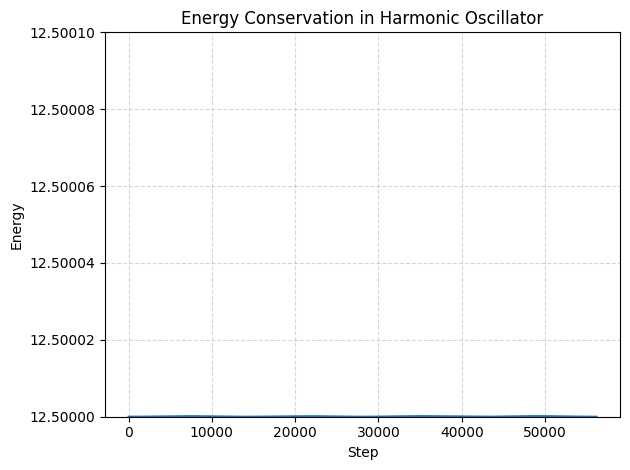

In [17]:
plt.plot(plot_E)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.xlabel('Step')
plt.ylabel('Energy')
plt.title('Energy Conservation in Harmonic Oscillator')
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(12.5, 12.5001)
plt.tight_layout()
plt.show()

### Result: Energy conservation
The total energy $E = \frac{p^2}{2m} + \frac{1}{2}k(x-x_0)^2$ should theoretically be a perfectly flat horizontal line indicating conservation of energy. In our plot, the energy stays nearly constant at `12.5` but shows extremely tiny numerical fluctuations. These small ripples are an artifact of the finite time-step (`dt`) used in the numerical integration method. Since the oscillations are bounded, the simulated system correctly preserves the structural stability of the phase-space ellipse.

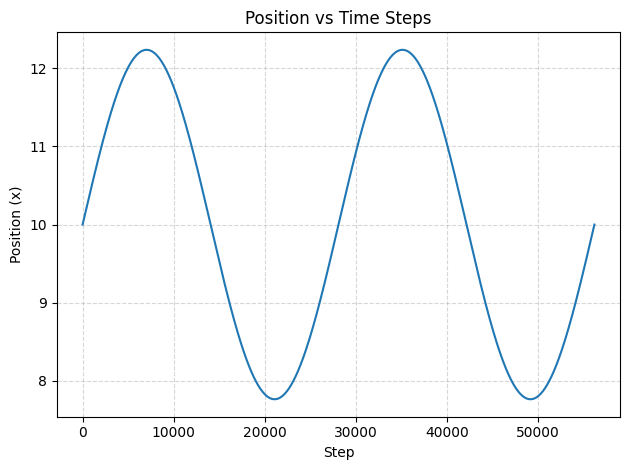

In [18]:
plt.plot(plot_x)
plt.xlabel('Step')
plt.ylabel('Position (x)')
plt.title('Position vs Time Steps')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Result: Position vs time
As the system traverses the phase-space ellipse $E = \frac{p^2}{2m} + \frac{1}{2}k(x-x_0)^2$, the position coordinates trace out a 1D projection of this rotation. This yields an expected sinusoidal graph roughly of the form $x(t) = x_0 + \sqrt{2E/k} \cos(\omega t)$. The stable repeating peaks and troughs illustrate the restoring force pushing the mass continuously back toward the equilibrium position $x_0 = 10$.

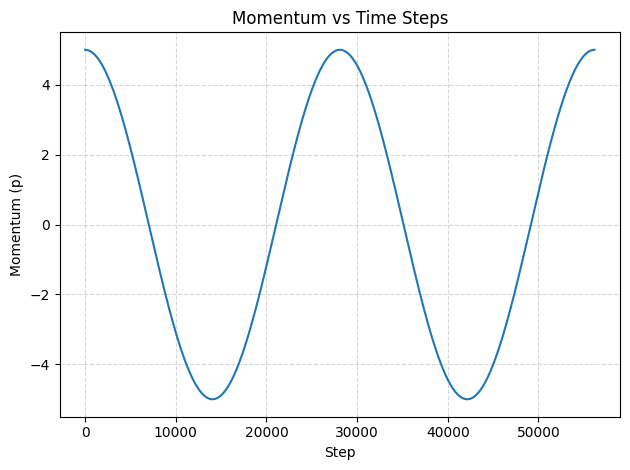

In [19]:
plt.plot(plot_p)
plt.xlabel('Step')
plt.ylabel('Momentum (p)')
plt.title('Momentum vs Time Steps')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Result: Momentum vs time
Similar to position, the momentum gives the vertical projection of the phase-space ellipse. It manifests as a sinusoidal wave roughly $\pi/2$ out of phase with the position: $p(t) = -\sqrt{2mE} \sin(\omega t)$. It oscillates symmetrically around zero, with peak magnitudes (when kinetic energy is maximal and the mass speeds past equilibrium) predictably capped at $\sqrt{2mE}$.

# Counting Number of Microstates

We create a grid of phase-space cells with width `dx` and height `dp`. Then, we keep an array of zeros and iterate through all simulated steps. For each step, we identify which grid cell the `(x[i], p[i])` point belongs to, and set that grid cell to 1. Finally, the sum of all 1s in the array gives the total number of unique microstates (cells) the trajectory passed through.

Unique phase-space cells visited: 286


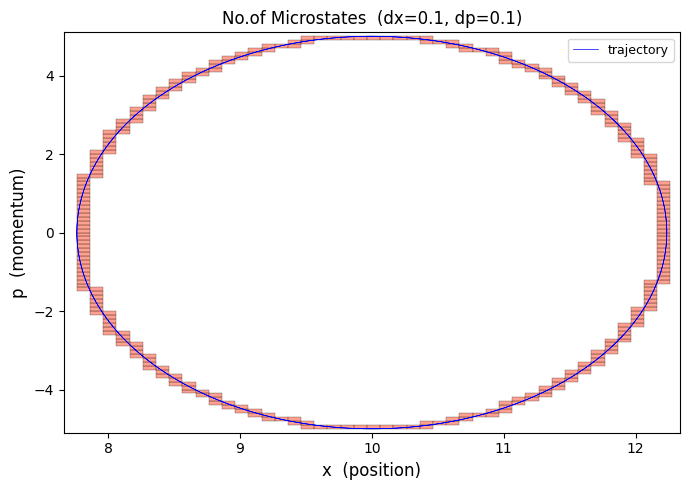

In [20]:
dx = 0.1
dp = 0.1

def count_unique_cells(x, p, dx, dp):
    xmin, xmax = min(x), max(x)
    pmin, pmax = min(p), max(p)
    xbins,pbins = int((xmax-xmin)/dx), int((pmax-pmin)/dp)
    grid = np.zeros((int(xbins)+1, int(pbins)+1))
    for i in range(steps):
        x_idx = int((x[i] - xmin) / dx)
        p_idx = int((p[i] - pmin) / dp)
        grid[x_idx][p_idx] = 1

    return np.count_nonzero(grid == 1), grid, xmin, xmax, pmin, pmax, xbins, pbins

fig, ax = plt.subplots(figsize=(7, 5))
states, grid, xmin, xmax, pmin, pmax, xbins, pbins = count_unique_cells(x, p, dx, dp)
print(f"Unique phase-space cells visited: {states}")
# --- trajectory ---
ax.plot(x, p, color="blue", linewidth=0.5, zorder=1, label="trajectory")

# --- colour visited rectangles ---
for ix in range(xbins + 1):
    for ip in range(pbins + 1):
        if grid[ix, ip] == 1:
            rect_x = xmin + ix * dx
            rect_p = pmin + ip * dp
            ax.add_patch(patches.Rectangle(
                (rect_x, rect_p), dx, dp,
                linewidth=0.3,
                edgecolor="black",
                facecolor="tomato",
                alpha=0.6,
                zorder=0,
            ))

ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(pmin - dp, pmax + dp)
ax.set_xlabel("x  (position)", fontsize=12)
ax.set_ylabel("p  (momentum)", fontsize=12)
ax.set_title(f"No.of Microstates  (dx={dx}, dp={dp})", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Result: Visited phase-space microstates
This graph visualizes the discretization of the analytical $E = \frac{p^2}{2m} + \frac{1}{2}k(x-x_0)^2$ ellipse into finite grid boxes of size $\Delta x \times \Delta p$. The highlighted rectangles essentially trace the perimeter of the ellipse. Since the energy dictates a strictly bounded 1D path in phase-space, the system only explores a finite, specific sequence of microstate cells rather than filling the entire phase space.

p_init=1.00 → Unique cells: 54
p_init=2.00 → Unique cells: 112
p_init=3.00 → Unique cells: 168
p_init=4.00 → Unique cells: 227
p_init=5.00 → Unique cells: 286
p_init=6.00 → Unique cells: 342
p_init=7.00 → Unique cells: 402
p_init=8.00 → Unique cells: 459
p_init=9.00 → Unique cells: 516
p_init=10.00 → Unique cells: 575
p_init=11.00 → Unique cells: 631
p_init=12.00 → Unique cells: 689
p_init=13.00 → Unique cells: 750
p_init=14.00 → Unique cells: 807
p_init=15.00 → Unique cells: 857
p_init=16.00 → Unique cells: 922
p_init=17.00 → Unique cells: 979
p_init=18.00 → Unique cells: 1034
p_init=19.00 → Unique cells: 1092
p_init=20.00 → Unique cells: 1149


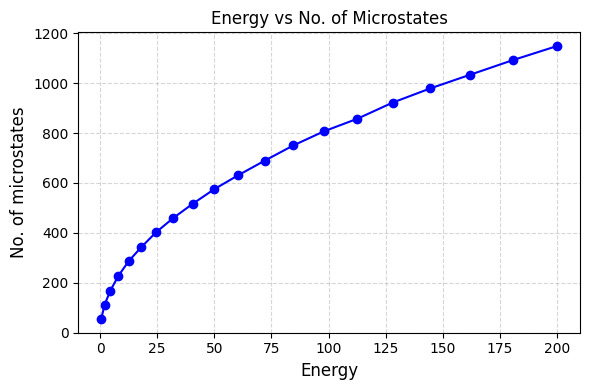

In [21]:
p_vals = np.linspace(1, 20, 20)
states = []
energy = []
for p_init in p_vals:
    x_new, p_new, _, _, _ = simul(steps, x0, p_init, k, m, dt)
    state, grid, xmin, xmax, pmin, pmax, xbins, pbins = count_unique_cells(x_new, p_new, dx, dp)
    states.append(state)
    energy.append((p_init**2) / (2 * m) + 0.5 * k * (x0 - x0)**2)
    print(f"p_init={p_init:.2f} → Unique cells: {state}")

plt.figure(figsize=(6, 4))
plt.plot(energy, states, marker="o", linestyle="-", color="blue")
plt.xlabel("Energy", fontsize=12)
plt.ylabel("No. of microstates", fontsize=12)
plt.title("Energy vs No. of Microstates", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

rootE = np.sqrt(energy)

### Result: Energy vs microstates
As we increase the initial momentum, the total energy $E$ of the system increases. Consequently, the semi-axes of the phase-space ellipse ($a = \sqrt{2E/k}$ and $b = \sqrt{2mE}$) also increase, visually enlarging the ellipse. Because the microstates are counted along the 1D perimeter of the trajectory, the number of visited grid cells directly corresponds to the circumference of this enlarged phase-space ellipse. The plot of Energy vs Microstates illustrates a sub-linear dependency, matching the mathematical reality that the circumference scales with the square root of energy.

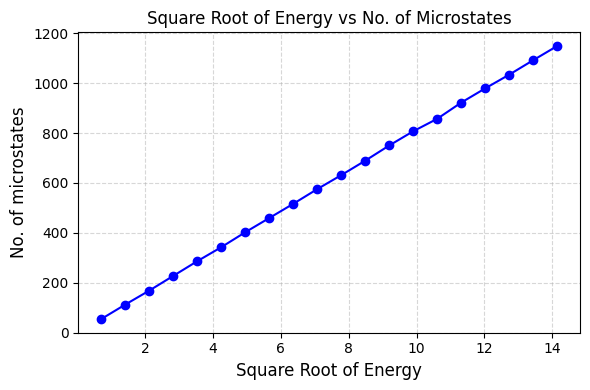

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(rootE, states, marker="o", linestyle="-", color="blue")
plt.xlabel("Square Root of Energy", fontsize=12)
plt.ylabel("No. of microstates", fontsize=12)
plt.title("Square Root of Energy vs No. of Microstates", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Result: Square-root energy scaling
Following the $E = \frac{p^2}{2m} + \frac{1}{2}k(x-x_0)^2$ formula, the semi-major and semi-minor bounds of the bounding ellipse both scale exactly by $\sqrt{E}$. Therefore, the perimeter of the ellipse—and the number of visited phase-space microstates it crosses—must scale linearly with $\sqrt{E}$. By plotting the microstate count against $\sqrt{E}$, we recover a very strong linear relationship, confirming the geometric predictions of classical hamiltonian mechanics for the harmonic oscillator.